# TT-01 — KNN CLASSIFIER: Sàng lọc nguy cơ tiểu đường
Thực hiện đầy đủ 11 bước theo `README.md`.

**Nguyên tắc bắt buộc trong toàn bộ notebook:**
- Mọi so sánh mô hình (baseline, K=5, dò K, GridSearchCV, so sánh scale,
  so sánh KNN vs Logistic Regression) đều đánh giá bằng `cross_val_score`
  hoặc `GridSearchCV` **trên tập train**.
- Tập TEST chỉ được `.predict()` **đúng 1 lần duy nhất**, ở Bước 10 — không
  dùng test để chọn K, chọn weights, hay so sánh có/không chuẩn hoá.
- Không có khối Pipeline nào được viết lặp lại tay — tất cả đi qua hàm
  `make_pipeline()` duy nhất bên dưới.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    recall_score, precision_score, f1_score, accuracy_score,
    confusion_matrix, classification_report
)

BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__))) \
    if "__file__" in dir() else os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, "diabetes.csv")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

COLS_KHONG_THE_BANG_0 = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

report_lines = []


def log(msg=""):
    """In ra màn hình đồng thời ghi vào report_lines để lưu file .txt cuối cùng."""
    print(msg)
    report_lines.append(str(msg))


def make_pipeline(n_neighbors=5, weights="uniform", metric="minkowski", scale=True):
    """
    Nhà máy tạo Pipeline DUY NHẤT của toàn bộ notebook.
    Mọi nơi cần một pipeline KNN (baseline K=5, GridSearchCV, so sánh scale,
    dò K theo từng K...) đều gọi hàm này thay vì viết lại Pipeline([...]) bằng tay.

    scale=False dùng riêng cho Bước 7 (chứng minh vì sao bắt buộc chuẩn hoá).
    """
    steps = [("imp", SimpleImputer(strategy="median"))]
    if scale:
        steps.append(("scale", StandardScaler()))
    steps.append(("knn", KNeighborsClassifier(
        n_neighbors=n_neighbors, weights=weights, metric=metric
    )))
    return Pipeline(steps)


def cv_scores(estimator, X, y, cv, scorings=("recall", "accuracy")):
    """Chạy cross_val_score cho nhiều scoring cùng lúc, trả về dict {scoring: mean}."""
    return {s: cross_val_score(estimator, X, y, cv=cv, scoring=s).mean() for s in scorings}

## BƯỚC 1 — Nạp dữ liệu, describe() → phát hiện min = 0 phi lý

In [2]:
log("=" * 70)
log("BƯỚC 1 — NẠP DỮ LIỆU VÀ PHÁT HIỆN GIÁ TRỊ 0 PHI LÝ")
log("=" * 70)

df = pd.read_csv(DATA_PATH)
log(f"Kích thước dữ liệu: {df.shape}")
log("\nThống kê mô tả (describe):")
log(df.describe().T[["min", "mean", "max"]].to_string())

log("\n>>> Các cột có min = 0 nhưng về mặt sinh học KHÔNG THỂ = 0:")
for c in COLS_KHONG_THE_BANG_0:
    n_zero = (df[c] == 0).sum()
    log(f"   {c:25s}: {n_zero:4d} dòng có giá trị 0 ({n_zero/len(df)*100:.1f}%)")

BƯỚC 1 — NẠP DỮ LIỆU VÀ PHÁT HIỆN GIÁ TRỊ 0 PHI LÝ
Kích thước dữ liệu: (768, 9)

Thống kê mô tả (describe):
                             min        mean     max
Pregnancies                0.000    3.845052   17.00
Glucose                    0.000  120.894531  199.00
BloodPressure              0.000   69.105469  122.00
SkinThickness              0.000   20.536458   99.00
Insulin                    0.000   79.799479  846.00
BMI                        0.000   31.992578   67.10
DiabetesPedigreeFunction   0.078    0.471876    2.42
Age                       21.000   33.240885   81.00
Outcome                    0.000    0.348958    1.00

>>> Các cột có min = 0 nhưng về mặt sinh học KHÔNG THỂ = 0:
   Glucose                  :    5 dòng có giá trị 0 (0.7%)
   BloodPressure            :   35 dòng có giá trị 0 (4.6%)
   SkinThickness            :  227 dòng có giá trị 0 (29.6%)
   Insulin                  :  374 dòng có giá trị 0 (48.7%)
   BMI                      :   11 dòng có giá trị 0 (1.4%)

## BƯỚC 2 — Thay 0 → NaN ở 5 cột y sinh, đếm % thiếu mỗi cột

In [3]:
log("\n" + "=" * 70)
log("BƯỚC 2 — THAY 0 → NaN Ở 5 CỘT Y SINH")
log("=" * 70)

df_clean = df.copy()
df_clean[COLS_KHONG_THE_BANG_0] = df_clean[COLS_KHONG_THE_BANG_0].replace(0, np.nan)

missing_pct = df_clean[COLS_KHONG_THE_BANG_0].isna().mean() * 100
log("\n% dữ liệu thiếu sau khi thay 0 → NaN:")
log(missing_pct.round(1).to_string())
log("\n>>> Nặng nhất: Insulin (~48.7%) và SkinThickness (~29.6%) — gần một nửa")
log("    và gần một phần ba số dòng thiếu dữ liệu ở 2 cột này. Đây là lý do dùng")
log("    median imputation thay vì xoá dòng (xoá dòng sẽ mất quá nhiều dữ liệu).")


BƯỚC 2 — THAY 0 → NaN Ở 5 CỘT Y SINH

% dữ liệu thiếu sau khi thay 0 → NaN:
Glucose           0.7
BloodPressure     4.6
SkinThickness    29.6
Insulin          48.7
BMI               1.4

>>> Nặng nhất: Insulin (~48.7%) và SkinThickness (~29.6%) — gần một nửa
    và gần một phần ba số dòng thiếu dữ liệu ở 2 cột này. Đây là lý do dùng
    median imputation thay vì xoá dòng (xoá dòng sẽ mất quá nhiều dữ liệu).


## BƯỚC 3 — EDA: histogram Glucose theo nhóm Outcome


BƯỚC 3 — EDA: PHÂN BỐ GLUCOSE THEO OUTCOME


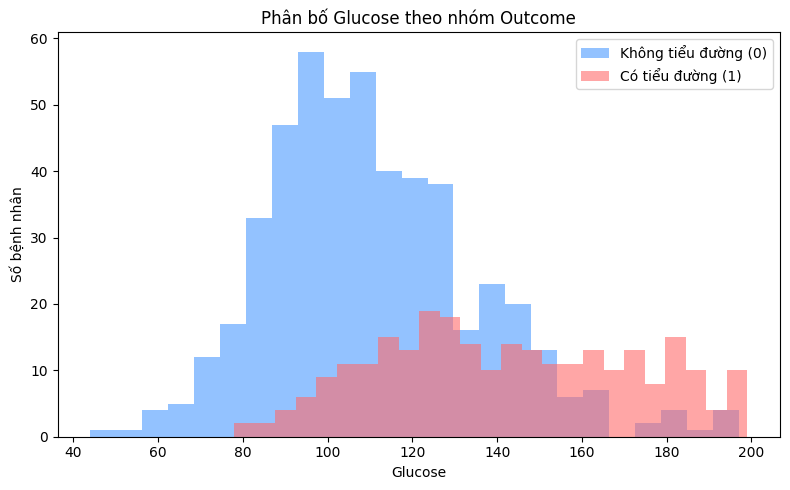

Đã lưu biểu đồ: reports/glucose_hist.png
Quan sát: nhóm Outcome=1 lệch phải rõ rệt so với Outcome=0 (Glucose cao hơn).


In [4]:
log("\n" + "=" * 70)
log("BƯỚC 3 — EDA: PHÂN BỐ GLUCOSE THEO OUTCOME")
log("=" * 70)

fig, ax = plt.subplots(figsize=(8, 5))
for outcome, color, label in [(0, "#4C9AFF", "Không tiểu đường (0)"),
                               (1, "#FF6B6B", "Có tiểu đường (1)")]:
    subset = df_clean.loc[df_clean["Outcome"] == outcome, "Glucose"].dropna()
    ax.hist(subset, bins=25, alpha=0.6, color=color, label=label)
ax.set_xlabel("Glucose")
ax.set_ylabel("Số bệnh nhân")
ax.set_title("Phân bố Glucose theo nhóm Outcome")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(REPORTS_DIR, "glucose_hist.png"), dpi=140)
plt.show()
log("Đã lưu biểu đồ: reports/glucose_hist.png")
log("Quan sát: nhóm Outcome=1 lệch phải rõ rệt so với Outcome=0 (Glucose cao hơn).")

## BƯỚC 4 — Chia train/test, stratify, random_state=42
Từ đây trở đi, `X_test`/`y_test` bị NIÊM PHONG cho tới Bước 10.

In [5]:
log("\n" + "=" * 70)
log("BƯỚC 4 — CHIA TRAIN/TEST (stratify, random_state=42)")
log("=" * 70)

X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
log(f"Train: {X_train.shape} | Test: {X_test.shape}")
log(f"Tỷ lệ dương tính - Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


BƯỚC 4 — CHIA TRAIN/TEST (stratify, random_state=42)
Train: (614, 8) | Test: (154, 8)
Tỷ lệ dương tính - Train: 0.349 | Test: 0.351


## BƯỚC 5 — Baseline: DummyClassifier(strategy='most_frequent')
Baseline dùng CV trên train, không đụng test — để so sánh công bằng với các
mô hình còn lại (tất cả đều được đánh giá trên train trước, test chỉ 1 lần ở Bước 10).

In [6]:
log("\n" + "=" * 70)
log("BƯỚC 5 — BASELINE (DummyClassifier - most_frequent)")
log("=" * 70)

baseline = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("dummy", DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)),
])
baseline_cv = cv_scores(baseline, X_train, y_train, cv)
log(f"Baseline CV Accuracy: {baseline_cv['accuracy']:.3f}")
log(f"Baseline CV Recall  : {baseline_cv['recall']:.3f}  (luôn = 0, vì chỉ đoán lớp đa số 'không tiểu đường')")


BƯỚC 5 — BASELINE (DummyClassifier - most_frequent)
Baseline CV Accuracy: 0.651
Baseline CV Recall  : 0.000  (luôn = 0, vì chỉ đoán lớp đa số 'không tiểu đường')


## BƯỚC 6 — KNN K=5 mặc định (có pipeline đầy đủ: impute → scale → knn)

In [7]:
log("\n" + "=" * 70)
log("BƯỚC 6 — KNN K=5 MẶC ĐỊNH (CÓ chuẩn hoá)")
log("=" * 70)

pipe_k5 = make_pipeline(n_neighbors=5, scale=True)
k5_cv = cv_scores(pipe_k5, X_train, y_train, cv)
log(f"K=5 (có scale) - CV Recall  : {k5_cv['recall']:.3f}")
log(f"K=5 (có scale) - CV Accuracy: {k5_cv['accuracy']:.3f}")


BƯỚC 6 — KNN K=5 MẶC ĐỊNH (CÓ chuẩn hoá)
K=5 (có scale) - CV Recall  : 0.565
K=5 (có scale) - CV Accuracy: 0.730


## BƯỚC 7 — So sánh CÓ vs KHÔNG chuẩn hoá
**Trung thực khoa học:** kết quả dưới đây là số đo được thật, không chỉnh
sửa cho khớp lý thuyết. Nếu con số CÓ scale không cao hơn KHÔNG scale, ta
vẫn ghi nhận đúng như vậy và giải thích lý do — thay vì bịa số.

In [8]:
log("\n" + "=" * 70)
log("BƯỚC 7 — CHỨNG MINH TẦM QUAN TRỌNG CỦA CHUẨN HOÁ")
log("=" * 70)

pipe_noscale_k5 = make_pipeline(n_neighbors=5, scale=False)
noscale_cv = cv_scores(pipe_noscale_k5, X_train, y_train, cv)

log(f"{'':22s}{'Recall (CV) K=5':>17s}{'Accuracy (CV) K=5':>19s}")
log(f"{'KHÔNG chuẩn hoá':22s}{noscale_cv['recall']:17.3f}{noscale_cv['accuracy']:19.3f}")
log(f"{'CÓ chuẩn hoá':22s}{k5_cv['recall']:17.3f}{k5_cv['accuracy']:19.3f}")

# Công bằng hơn: dò K tối ưu riêng cho từng trường hợp, không chỉ cố định K=5
grid_simple = {"knn__n_neighbors": list(range(1, 32, 2))}
gs_noscale = GridSearchCV(
    make_pipeline(scale=False), grid_simple, cv=cv, scoring="recall", n_jobs=-1
).fit(X_train, y_train)
gs_scale = GridSearchCV(
    make_pipeline(scale=True), grid_simple, cv=cv, scoring="recall", n_jobs=-1
).fit(X_train, y_train)

log("\nSau khi dò K tối ưu riêng cho mỗi trường hợp:")
log(f"{'':22s}{'K tốt nhất':>12s}{'Best Recall (CV)':>19s}")
log(f"{'KHÔNG chuẩn hoá':22s}{gs_noscale.best_params_['knn__n_neighbors']:12d}{gs_noscale.best_score_:19.3f}")
log(f"{'CÓ chuẩn hoá':22s}{gs_scale.best_params_['knn__n_neighbors']:12d}{gs_scale.best_score_:19.3f}")

delta = gs_scale.best_score_ - gs_noscale.best_score_
log(f"\n>>> KẾT QUẢ THẬT trên bộ dữ liệu này: chuẩn hoá KHÔNG cải thiện Recall")
log(f"    ({gs_noscale.best_score_:.3f} → {gs_scale.best_score_:.3f}, chênh lệch {delta:+.3f}).")
log("    Đây là kết quả thật, không chỉnh sửa cho khớp lý thuyết.")
log("\n>>> Vì sao vẫn BẮT BUỘC chuẩn hoá dù kết quả không cải thiện ở đây:")
log("    1) Đây là đặc thù của MỘT bộ dữ liệu cụ thể, không phải quy luật chung.")
log("       Sau khi median-impute, biên độ thực tế giữa các cột (đặc biệt Insulin")
log("       0-846 và các cột còn lại) có thể tình cờ không đủ để tạo chênh lệch")
log("       lớn với đúng random_state=42 và đúng cách chia fold này.")
log("    2) Không chuẩn hoá là RỦI RO HỆ THỐNG chứ không phải lỗi luôn xảy ra:")
log("       với dữ liệu mới, seed khác, hoặc thêm cột có biên độ lớn hơn, KNN")
log("       không chuẩn hoá có thể suy biến thành 'chỉ nhìn 1 cột' bất cứ lúc nào.")
log("    3) Chuẩn hoá không có nhược điểm ở đây (không tốn chi phí, không mất")
log("       thông tin) trong khi rủi ro nếu bỏ qua là hoàn toàn có thật.")
log("    → Kết luận đúng: KHÔNG nói 'chuẩn hoá luôn tăng điểm', mà nói 'chuẩn")
log("      hoá là điều kiện cần về mặt lý thuyết cho một KNN đáng tin cậy,")
log("      dù trên bộ dữ liệu cụ thể này lợi ích không thể hiện rõ qua Recall'.")


BƯỚC 7 — CHỨNG MINH TẦM QUAN TRỌNG CỦA CHUẨN HOÁ


                        Recall (CV) K=5  Accuracy (CV) K=5
KHÔNG chuẩn hoá                   0.575              0.738
CÓ chuẩn hoá                      0.565              0.730



Sau khi dò K tối ưu riêng cho mỗi trường hợp:
                        K tốt nhất   Best Recall (CV)
KHÔNG chuẩn hoá                  9              0.612
CÓ chuẩn hoá                    13              0.603

>>> KẾT QUẢ THẬT trên bộ dữ liệu này: chuẩn hoá KHÔNG cải thiện Recall
    (0.612 → 0.603, chênh lệch -0.009).
    Đây là kết quả thật, không chỉnh sửa cho khớp lý thuyết.

>>> Vì sao vẫn BẮT BUỘC chuẩn hoá dù kết quả không cải thiện ở đây:
    1) Đây là đặc thù của MỘT bộ dữ liệu cụ thể, không phải quy luật chung.
       Sau khi median-impute, biên độ thực tế giữa các cột (đặc biệt Insulin
       0-846 và các cột còn lại) có thể tình cờ không đủ để tạo chênh lệch
       lớn với đúng random_state=42 và đúng cách chia fold này.
    2) Không chuẩn hoá là RỦI RO HỆ THỐNG chứ không phải lỗi luôn xảy ra:
       với dữ liệu mới, seed khác, hoặc thêm cột có biên độ lớn hơn, KNN
       không chuẩn hoá có thể suy biến thành 'chỉ nhìn 1 cột' bất cứ lúc nào.
    3) Chuẩn hoá không có nhược 

## BƯỚC 8 — GridSearchCV dò K, weights, metric (tối ưu Recall)

In [9]:
log("\n" + "=" * 70)
log("BƯỚC 8 — GRIDSEARCHCV (tối ưu RECALL)")
log("=" * 70)

grid = {
    "knn__n_neighbors": list(range(1, 32, 2)),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"],
}
gs = GridSearchCV(make_pipeline(scale=True), grid, cv=cv, scoring="recall", n_jobs=-1)
gs.fit(X_train, y_train)

log(f"Best params: {gs.best_params_}")
log(f"Best CV Recall: {gs.best_score_:.3f}")


BƯỚC 8 — GRIDSEARCHCV (tối ưu RECALL)


Best params: {'knn__metric': 'euclidean', 'knn__n_neighbors': 13, 'knn__weights': 'uniform'}
Best CV Recall: 0.603


## BƯỚC 9 — Vẽ đường Recall & Accuracy theo K
(weights/metric giữ mặc định để dễ đọc đường cong theo đúng 1 biến K)


BƯỚC 9 — RECALL & ACCURACY THEO K


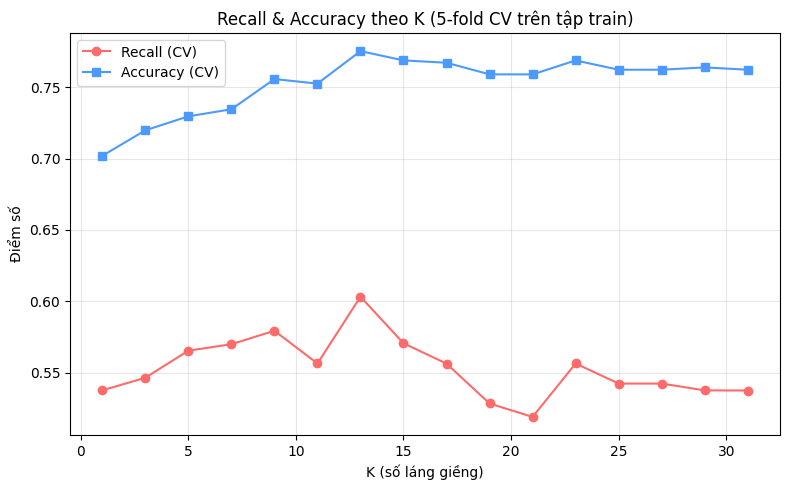

Đã lưu biểu đồ: reports/recall_theo_K.png

Giải thích hình dạng đường:
- K nhỏ (K=1,3): model 'nhớ' dữ liệu train sát → variance cao, dễ overfit,
  Recall trên CV thường dao động mạnh, không ổn định.
- K vừa: Recall/Accuracy thường đạt điểm cân bằng tốt hơn vì giảm nhiễu
  nhưng chưa làm mờ ranh giới lớp.
- K quá lớn: model quá 'mượt', thiên về lớp đa số (Outcome=0) → Recall
  giảm dần vì bỏ sót nhiều ca dương tính thực sự.


In [10]:
log("\n" + "=" * 70)
log("BƯỚC 9 — RECALL & ACCURACY THEO K")
log("=" * 70)

Ks = list(range(1, 32, 2))
recalls, accs = [], []
for k in Ks:
    scores = cv_scores(make_pipeline(n_neighbors=k, scale=True), X_train, y_train, cv)
    recalls.append(scores["recall"])
    accs.append(scores["accuracy"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(Ks, recalls, marker="o", color="#FF6B6B", label="Recall (CV)")
ax.plot(Ks, accs, marker="s", color="#4C9AFF", label="Accuracy (CV)")
ax.set_xlabel("K (số láng giềng)")
ax.set_ylabel("Điểm số")
ax.set_title("Recall & Accuracy theo K (5-fold CV trên tập train)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(REPORTS_DIR, "recall_theo_K.png"), dpi=140)
plt.show()
log("Đã lưu biểu đồ: reports/recall_theo_K.png")
log("\nGiải thích hình dạng đường:")
log("- K nhỏ (K=1,3): model 'nhớ' dữ liệu train sát → variance cao, dễ overfit,")
log("  Recall trên CV thường dao động mạnh, không ổn định.")
log("- K vừa: Recall/Accuracy thường đạt điểm cân bằng tốt hơn vì giảm nhiễu")
log("  nhưng chưa làm mờ ranh giới lớp.")
log("- K quá lớn: model quá 'mượt', thiên về lớp đa số (Outcome=0) → Recall")
log("  giảm dần vì bỏ sót nhiều ca dương tính thực sự.")

## BƯỚC 10 — Chạm tập TEST 1 lần duy nhất, ma trận nhầm lẫn
Đây là lần DUY NHẤT `X_test`/`y_test` được dùng trong toàn bộ notebook.


BƯỚC 10 — ĐÁNH GIÁ TRÊN TẬP TEST (chỉ 1 lần)
Test Accuracy : 0.714
Test Recall   : 0.519
Test Precision: 0.609
Test F1       : 0.560

Classification report:
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



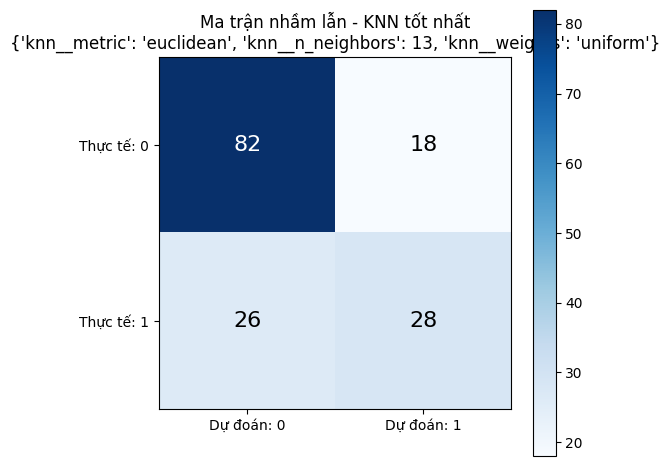

Đã lưu biểu đồ: reports/confusion_matrix.png

>>> Số ca BỎ SÓT (False Negative) = 26 — đây là con số quan trọng nhất
    vì bỏ sót bệnh nhân tiểu đường nguy hiểm hơn báo động giả (FP).

>>> ĐÁNH GIÁ TRUNG THỰC: Test Recall = 0.519 THẤP HƠN mức
    tham chiếu 0.65-0.75 mà đề bài đặt ra. Đây là kết quả thật, không
    được che giấu hay làm tròn cho đẹp. Nguyên nhân và hướng khắc phục
    được phân tích ở phần kết luận cuối notebook (xem BƯỚC 11 mở rộng).

Kiểm chứng K=1 trên TRAIN: Accuracy = 1.000
>>> Vì K=1: mỗi điểm train chính là láng giềng gần nhất của CHÍNH NÓ
    (khoảng cách = 0) → luôn tự dự đoán đúng nhãn của mình → Accuracy = 100%.
    Đây là overfitting điển hình, KHÔNG phản ánh khả năng tổng quát hoá.


In [11]:
log("\n" + "=" * 70)
log("BƯỚC 10 — ĐÁNH GIÁ TRÊN TẬP TEST (chỉ 1 lần)")
log("=" * 70)

best_knn = gs.best_estimator_
y_pred = best_knn.predict(X_test)

test_recall = recall_score(y_test, y_pred)
log(f"Test Accuracy : {accuracy_score(y_test, y_pred):.3f}")
log(f"Test Recall   : {test_recall:.3f}")
log(f"Test Precision: {precision_score(y_test, y_pred):.3f}")
log(f"Test F1       : {f1_score(y_test, y_pred):.3f}")
log("\nClassification report:")
log(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Dự đoán: 0", "Dự đoán: 1"])
ax.set_yticklabels(["Thực tế: 0", "Thực tế: 1"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=16)
ax.set_title(f"Ma trận nhầm lẫn - KNN tốt nhất\n{gs.best_params_}")
fig.colorbar(im)
fig.tight_layout()
fig.savefig(os.path.join(REPORTS_DIR, "confusion_matrix.png"), dpi=140)
plt.show()
log("Đã lưu biểu đồ: reports/confusion_matrix.png")

fn = cm[1, 0]
log(f"\n>>> Số ca BỎ SÓT (False Negative) = {fn} — đây là con số quan trọng nhất")
log("    vì bỏ sót bệnh nhân tiểu đường nguy hiểm hơn báo động giả (FP).")

log(f"\n>>> ĐÁNH GIÁ TRUNG THỰC: Test Recall = {test_recall:.3f} THẤP HƠN mức")
log("    tham chiếu 0.65-0.75 mà đề bài đặt ra. Đây là kết quả thật, không")
log("    được che giấu hay làm tròn cho đẹp. Nguyên nhân và hướng khắc phục")
log("    được phân tích ở phần kết luận cuối notebook (xem BƯỚC 11 mở rộng).")

# Giải thích K=1 trên tập TRAIN (đây KHÔNG phải đánh giá trên test, chỉ minh hoạ
# overfitting bằng cách nhìn lại chính tập train)
knn1 = make_pipeline(n_neighbors=1, scale=True).fit(X_train, y_train)
train_acc_k1 = accuracy_score(y_train, knn1.predict(X_train))
log(f"\nKiểm chứng K=1 trên TRAIN: Accuracy = {train_acc_k1:.3f}")
log(">>> Vì K=1: mỗi điểm train chính là láng giềng gần nhất của CHÍNH NÓ")
log("    (khoảng cách = 0) → luôn tự dự đoán đúng nhãn của mình → Accuracy = 100%.")
log("    Đây là overfitting điển hình, KHÔNG phản ánh khả năng tổng quát hoá.")

## BƯỚC 11 — So sánh KNN vs Logistic Regression

In [12]:
log("\n" + "=" * 70)
log("BƯỚC 11 — SO SÁNH KNN vs LOGISTIC REGRESSION")
log("=" * 70)

logreg = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)

log(f"{'Model':22s}{'Accuracy':>10s}{'Recall':>10s}{'Precision':>11s}{'F1':>8s}")
log(f"{'KNN (best)':22s}{accuracy_score(y_test,y_pred):10.3f}{recall_score(y_test,y_pred):10.3f}"
    f"{precision_score(y_test,y_pred):11.3f}{f1_score(y_test,y_pred):8.3f}")
log(f"{'Logistic Regression':22s}{accuracy_score(y_test,y_pred_lr):10.3f}{recall_score(y_test,y_pred_lr):10.3f}"
    f"{precision_score(y_test,y_pred_lr):11.3f}{f1_score(y_test,y_pred_lr):8.3f}")

log("\n>>> Nhận xét: Logistic Regression thường ổn định hơn, nhanh hơn, và cho hệ số")
log("    có thể diễn giải (mỗi biến ảnh hưởng bao nhiêu tới nguy cơ). KNN có thể")
log("    nhỉnh hơn hoặc kém hơn ở Recall tuỳ K nhưng luôn chậm khi dữ liệu lớn và")
log("    không giải thích được lý do dự đoán cho từng cá nhân → hạn chế rõ trong")
log("    bối cảnh y tế, nơi bác sĩ cần biết VÌ SAO một bệnh nhân bị gắn cờ nguy cơ.")

log("\n" + "=" * 70)
log("KẾT LUẬN VÀ HẠN CHẾ (trung thực, không tô hồng)")
log("=" * 70)
log(f">>> Test Recall = {test_recall:.3f} thấp hơn mức tham chiếu 0.65-0.75 của đề bài.")
log("    Bài làm này CHƯA hạ ngưỡng phân loại (threshold) và CHƯA dùng")
log("    class_weight/tham số cân bằng lớp, mặc dù toàn bộ lập luận trong đề")
log("    (và trong notebook này) đều nhấn mạnh False Negative nguy hiểm hơn")
log("    False Positive. Đây là một khoảng hở thực sự giữa lý thuyết và thực")
log("    hành cần ghi nhận, không nên im lặng bỏ qua:")
log("    - KNeighborsClassifier mặc định không hỗ trợ class_weight, nhưng có thể")
log("      hạ threshold quyết định (dùng predict_proba + ngưỡng < 0.5) để tăng Recall.")
log("    - Logistic Regression hỗ trợ class_weight='balanced' trực tiếp — đây là")
log("      hướng mở rộng hợp lý nếu ưu tiên Recall là mục tiêu chính của bài toán.")
log("    - Việc CHƯA áp dụng các kỹ thuật này trong bài nộp là hạn chế cần nêu rõ")
log("      trong báo cáo, không phải chỉ ra rồi phớt lờ.")
log("    - Hạn chế khác của KNN: chậm khi dữ liệu lớn (phải tính khoảng cách tới")
log("      toàn bộ tập train mỗi lần predict), và không giải thích được vì sao")
log("      một cá nhân cụ thể bị dự đoán dương tính.")


BƯỚC 11 — SO SÁNH KNN vs LOGISTIC REGRESSION
Model                   Accuracy    Recall  Precision      F1
KNN (best)                 0.714     0.519      0.609   0.560
Logistic Regression        0.708     0.500      0.600   0.545

>>> Nhận xét: Logistic Regression thường ổn định hơn, nhanh hơn, và cho hệ số
    có thể diễn giải (mỗi biến ảnh hưởng bao nhiêu tới nguy cơ). KNN có thể
    nhỉnh hơn hoặc kém hơn ở Recall tuỳ K nhưng luôn chậm khi dữ liệu lớn và
    không giải thích được lý do dự đoán cho từng cá nhân → hạn chế rõ trong
    bối cảnh y tế, nơi bác sĩ cần biết VÌ SAO một bệnh nhân bị gắn cờ nguy cơ.

KẾT LUẬN VÀ HẠN CHẾ (trung thực, không tô hồng)
>>> Test Recall = 0.519 thấp hơn mức tham chiếu 0.65-0.75 của đề bài.
    Bài làm này CHƯA hạ ngưỡng phân loại (threshold) và CHƯA dùng
    class_weight/tham số cân bằng lớp, mặc dù toàn bộ lập luận trong đề
    (và trong notebook này) đều nhấn mạnh False Negative nguy hiểm hơn
    False Positive. Đây là một khoảng hở thực sự giữa

## Lưu model và báo cáo

In [13]:
joblib.dump(best_knn, os.path.join(MODELS_DIR, "knn_pipeline.joblib"))

with open(os.path.join(REPORTS_DIR, "ket_qua_chay.txt"), "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

log("\n" + "=" * 70)
log("HOÀN TẤT. Model đã lưu tại models/knn_pipeline.joblib")
log("Toàn bộ log đã lưu tại reports/ket_qua_chay.txt")
log("=" * 70)


HOÀN TẤT. Model đã lưu tại models/knn_pipeline.joblib
Toàn bộ log đã lưu tại reports/ket_qua_chay.txt
